# Gradient Boosting Models Exercise: Advanced Ensemble Methods

**ML2 Course - Extra Points Assignment (5 points)**

**Objective:**
The goal of this exercise is to explore and master various gradient boosting algorithms for panel data modeling. You will implement and compare seven state-of-the-art boosting models that represent the cutting edge of machine learning regression techniques.

**Models to Implement:**

1. **AdaBoost** ([AdaBoostRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html)) - Adaptive Boosting, the pioneering boosting algorithm
2. **GBM** ([GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)) - Classic Gradient Boosting Machine from scikit-learn
3. **GBM Histogram** ([HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html)) - Histogram-based Gradient Boosting (faster, inspired by LightGBM)
4. **XGBoost** ([XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor)) - Extreme Gradient Boosting, industry standard
5. **LightGBM** ([LGBMRegressor](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html)) - Light Gradient Boosting Machine, optimized for speed and memory
6. **CatBoost** ([CatBoostRegressor](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor)) - Categorical Boosting, handles categorical features natively
7. **XGBoostLSS** ([XGBoostLSS](https://github.com/StatMixedML/XGBoostLSS)) - XGBoost for Location, Scale and Shape, probabilistic predictions

**Tasks Workflow:**

Following a similar process to the SVM / KNN model (`notebooks/07.knn-model.ipynb`):

1. **Load the prepared training data** from the preprocessing step
2. **Feature Engineering** (if necessary):
   - Note: Tree-based models do NOT require standardization/normalization
   - They are invariant to monotonic transformations of features
3. **Feature Selection**:
   - Use existing feature rankings from `feature_ranking.xlsx` for initial feature selection
   - Consider feature importance from tree-based models
   - Test multiple feature sets (top 20, 30, 50 features, etc.) - please utilize Feature Importance directly from models
4. **Hyperparameter Tuning**: (2 points)
   - Use GridSearchCV or RandomizedSearchCV, or Optuna
   - Focus on key parameters: learning rate, boosting iterations, tree max depth, regularization (if applicable) etc.
   - Use rolling window cross-validation to avoid data leakage
5. **Identify Local Champions**: (1 point)
   - Select the best model for each algorithm class
   - Compare based on RMSE on validation sets
6. **Save Models**:
   - Pickle the best models for each algorithm
   - Save to `../models/` directory

**Important Notes:**

- Gradient boosting models are powerful but prone to overfitting - pay attention to regularization
- Learning rate and number of estimators have an inverse relationship
- Early stopping can be used to prevent overfitting
- XGBoostLSS provides distributional forecasts (not just point estimates)
- Use time-series aware cross-validation (rolling window) for final model selection

**Model Evaluation:** (2 points)

After completing this notebook:
- Load your models in `notebooks/09.final-comparison-and-summary.ipynb`
- Compare them against existing models (OLS, ARMA, ARDL, KNN, SVR)
- Check if any gradient boosting model becomes the new champion!

---

## Submission Requirements

- Complete this notebook with code and outputs
- Save best model(s) as pickle files in `models/` directory
- Commit and push to your GitHub repository
- Send repository link to: **mj.wozniak9@uw.edu.pl**

**Deadline:** [To be announced by instructor]

## Dependencies loading

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool

# XGBoostLSS Handling
try:
    import xgboost as xgb
    from xgboostlss.model import XGBoostLSS
    from xgboostlss.distributions.Gaussian import Gaussian
    HAS_LSS = True
except ImportError:
    print(" XGBoostLSS or dependencies not found. LSS model will be skipped.")
    HAS_LSS = False

# Evaluation & Tuning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error
import optuna
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Helper Functions

In [2]:
def clean_cols(cols):
    return [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in cols]

In [3]:
def calculate_crps_gaussian(y_true, mu, sigma):

    sigma = np.clip(sigma, 1e-3, np.inf)
    z = (y_true - mu) / sigma
    pdf = norm.pdf(z)
    cdf = norm.cdf(z)
    crps = sigma * (z * (2 * cdf - 1) + 2 * pdf - 1 / np.sqrt(np.pi))
    return np.mean(crps)

In [4]:
def calculate_nll_gaussian(y_true, mu, sigma, sigma_floor=1e-6, assume_variance=False):

    y = np.asarray(y_true).astype(float)
    mu = np.asarray(mu).astype(float)
    sigma = np.asarray(sigma).astype(float)

    if assume_variance:
        # if model returned variance, convert to std
        sigma = np.sqrt(np.clip(sigma, 1e-3, np.inf))

    # apply floor (std dev)
    sigma = np.clip(sigma, sigma_floor, np.inf)

    # stable NLL: 0.5*log(2*pi) + log(sigma) + 0.5*((y-mu)/sigma)^2
    nll_per = 0.5 * np.log(2 * np.pi) + np.log(sigma) + 0.5 * ((y - mu) / sigma) ** 2
    return np.mean(nll_per)

## Load the prepared training dataloading

In [5]:
preprocessed_output_path = "../data/output"
if not os.path.exists(preprocessed_output_path):
    os.makedirs(preprocessed_output_path)
    pass

df = pd.read_csv(f"{preprocessed_output_path}/train_fe.csv", index_col=0)
fr = pd.read_excel(f"{preprocessed_output_path}/feature_ranking.xlsx", index_col=0)

## Feature engineering for models

In [6]:
df.info()
df.dtypes
col_object = df.select_dtypes(include=['object']).columns.tolist()
print(col_object)

<class 'pandas.core.frame.DataFrame'>
Index: 3993 entries, 0 to 4354
Columns: 115 entries, Ticker to cash_holdings_past
dtypes: float64(57), int64(56), object(2)
memory usage: 3.5+ MB
['Ticker', 'Nazwa2']


In [7]:
df.columns = clean_cols(df.columns)
if 'fr' in locals():
    fr.index = clean_cols(fr.index)

In [8]:
# Some models require labeling of object types.
# Since these object columns are categorical variables, we can use LabelEncoder.
col_object_names_raw = ['Ticker', 'Nazwa2']
cleaned_object_names = clean_cols(col_object_names_raw)

for col in cleaned_object_names:
    if col in df.columns:
        df[col] = df[col].astype(str)
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Encoded '{col}'")
    else:
        print(f"Column '{col}' not found in DataFrame")

target_col = 'etr'

Encoded 'Ticker'
Encoded 'Nazwa2'


In [9]:
df.info()
print(df.head(5))
print(df.tail(5))

<class 'pandas.core.frame.DataFrame'>
Index: 3993 entries, 0 to 4354
Columns: 115 entries, Ticker to cash_holdings_past
dtypes: float64(57), int64(58)
memory usage: 3.5 MB
   Ticker  Nazwa2   rok         ta      txt        pi   str  xrd      ni  \
0       0       1  2005  21.127613  1.24185  6.329725  0.19  0.0  5.0879   
1       0       1  2006  21.127613  1.24185  6.329725  0.19  0.0  5.0879   
2       0       1  2007  21.127613  1.24185  6.329725  0.19  0.0  5.0879   
3       0       1  2008  21.127613  1.24185  6.329725  0.19  0.0  5.0879   
4       0       1  2009  21.127613  1.24185  6.329725  0.19  0.0  5.0879   

      ppent  ...  intan_ma    ppe_ma   sale_ma  cash_holdings_ma  roa_past  \
0  0.276275  ...  0.198598  0.013076  0.445954          0.574744  0.240818   
1  0.276275  ...  0.198598  0.013076  0.445954          0.574744  0.240818   
2  0.276275  ...  0.198598  0.013076  0.445954          0.574744  0.240818   
3  0.276275  ...  0.198598  0.013076  0.445954          0.5

## Feature selection

In [10]:
if 'mi_score' in fr.columns:
    fr.sort_values('mi_score', ascending=False, inplace=True)

In [11]:
boruta_features = []
if "boruta_rank" in fr.columns:
    boruta_features = fr[fr['boruta_rank'].isin([1, 2, 3])].index.tolist()

In [12]:
mi_features_10 = fr.iloc[0:10].index.tolist()
mi_features_30 = fr.iloc[0:30].index.tolist()

In [13]:
corr_features_20 = []
if "corr" in fr.columns:
    fr["corr_abs"] = np.abs(fr["corr"])
    fr_corr = fr.sort_values("corr_abs", ascending=False)
    corr_features_20 = fr_corr.iloc[0:20].index.tolist()

In [14]:
feature_sets_raw = {
    "boruta_top3": boruta_features,
    "mi_top10": mi_features_10,
    "mi_top30": mi_features_30,
    "corr_top20": corr_features_20
}

target_col = 'etr'

In [15]:
cleaned_feature_sets = {}
print("\nBuilding Cleaned Feature Sets:")
for name, features in feature_sets_raw.items():
    cleaned_names = clean_cols(features)

    valid_features = [f for f in cleaned_names if f in df.columns]

    if target_col in valid_features:
        valid_features.remove(target_col)

    if len(valid_features) > 0:
        cleaned_feature_sets[name] = valid_features
        print(f"  Set '{name}': {len(valid_features)} features ready.")
    else:
        print(f" Set '{name}': 0 features match. Skipped.")

# Fallback
if not cleaned_feature_sets:
    print(" No features matched. Using all numeric columns as fallback.")
    all_nums = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in all_nums: all_nums.remove(target_col)
    cleaned_feature_sets["all_features"] = all_nums


Building Cleaned Feature Sets:
  Set 'boruta_top3': 9 features ready.
  Set 'mi_top10': 10 features ready.
  Set 'mi_top30': 30 features ready.
  Set 'corr_top20': 20 features ready.


### Feature Importance Analysis by XGBoost

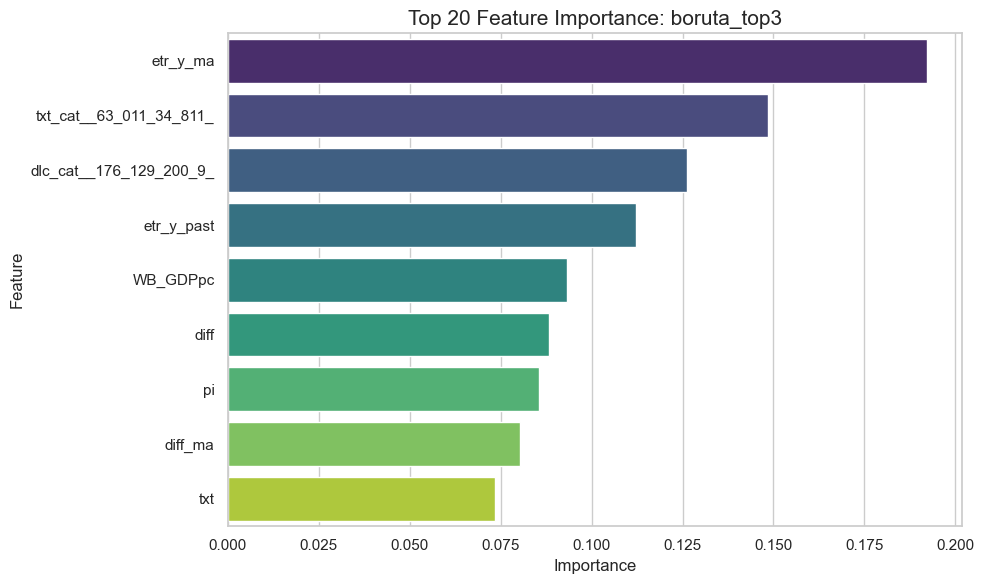

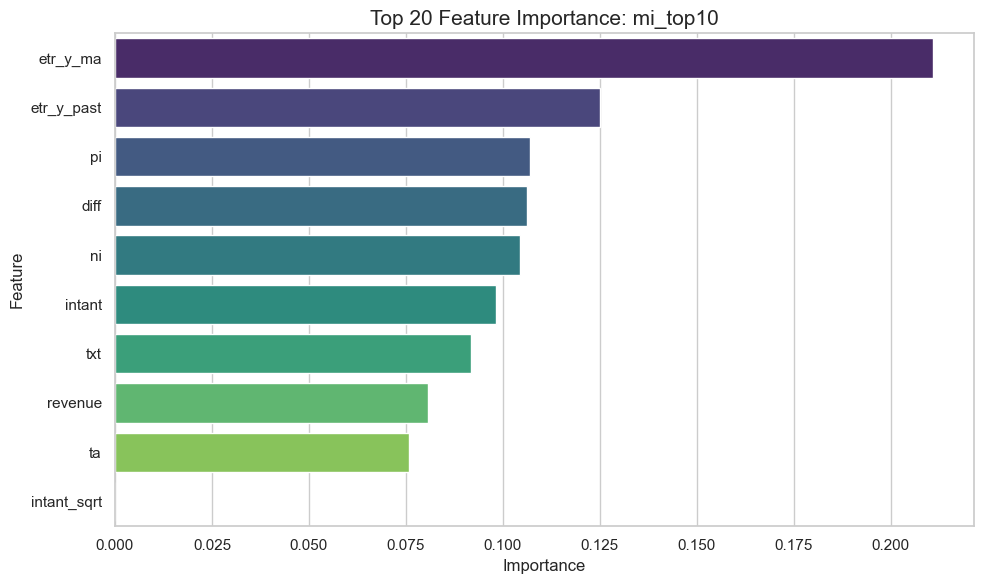

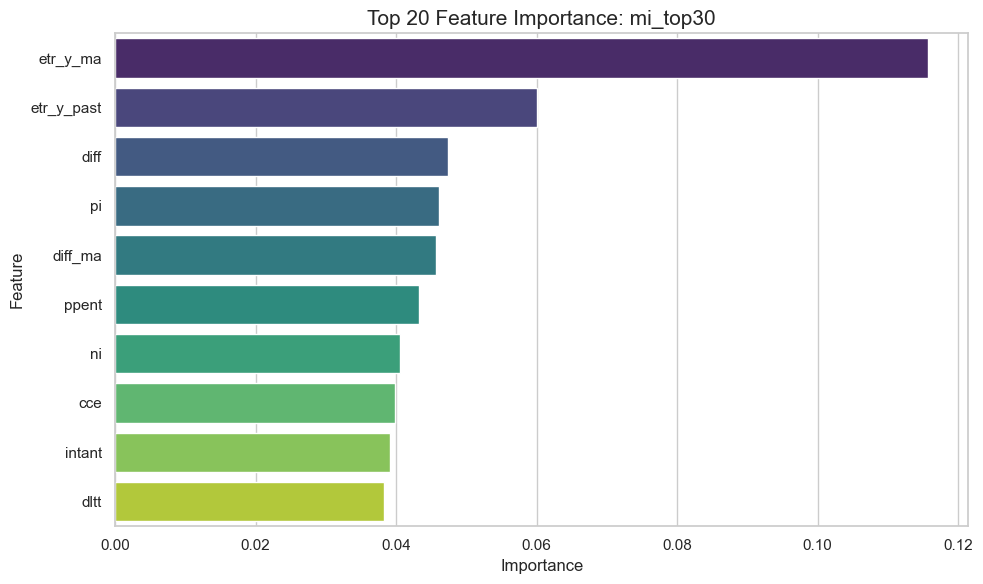

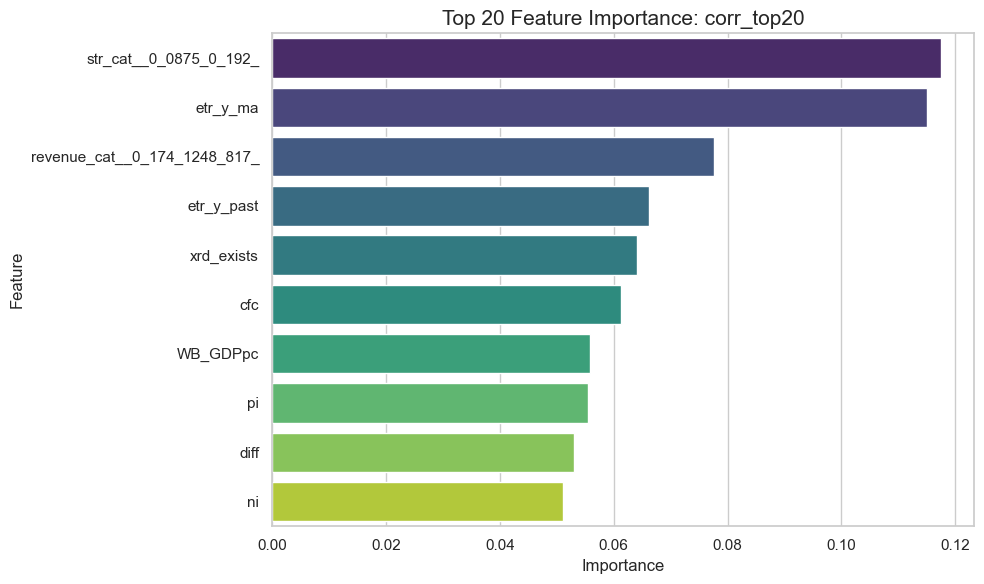

In [16]:
sns.set(style="whitegrid")

for set_name, feature_list in cleaned_feature_sets.items():
    # Data Preparation
    X_subset = df[feature_list].select_dtypes(include=[np.number])
    y_subset = df[target_col]

    X_subset.columns = (
        X_subset.columns.astype(str)
        .str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
    )

    # Train the model
    model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
        subsample=0.8,
        eta=0.1,
        min_child_weight=3
    )
    model.fit(X_subset, y_subset)

    importances = model.feature_importances_
    feature_names = X_subset.columns

    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    imp_df = imp_df.sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis', orient='h')
    plt.title(f"Top 20 Feature Importance: {set_name}", fontsize=15)
    plt.tight_layout()
    plt.show()

In [17]:
top10_xgb_features = imp_df['Feature'].values.tolist()
cleaned_feature_sets["xgb_importance_top10"] = top10_xgb_features
print("Added 'xgb_importance_top10' to feature sets.")

Added 'xgb_importance_top10' to feature sets.


### Train-Test Split

In [18]:
test_ratio = 0.2
split_index = int(len(df) * (1 - test_ratio))

df_train = df.iloc[:split_index].copy()
df_test = df.iloc[split_index:].copy() # Hold-out data

print(f"Data Split Summary:")
print(f"  Train samples: {len(df_train)}")
print(f"  Test samples:  {len(df_test)} (For final evaluation)")

# TimeSeriesSplit for CV (Valid on Train data)
n_splits = 5
#Set rolling window size
window_size = int(len(df_train) * 0.3)
tscv = TimeSeriesSplit(n_splits=n_splits, max_train_size=window_size)


Data Split Summary:
  Train samples: 3194
  Test samples:  799 (For final evaluation)


### Base Model Training and Evaluation

In [20]:
print("\n=== Running Baseline Evaluation (Default Params) on Train Data ===")

default_models = {
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "GBM": GradientBoostingRegressor(random_state=42),
    "HistGBM": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_jobs=-1, random_state=42, enable_categorical=False),
    "LightGBM": LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False)
}

baseline_results = []

for f_set_name, feature_list in cleaned_feature_sets.items():
    print(f"\n--- Testing Feature Set: {f_set_name} ---")

    # Prepare Data
    X_base = df_train[feature_list].copy()
    y_base = df_train[target_col]

    # Clean column names
    X_base.columns = clean_cols(X_base.columns)
    current_cat_cols = [c for c in X_base.columns if c in cleaned_object_names]

    for name, model in default_models.items():
        try:
            X_curr = X_base.copy()

            if name in ["LightGBM", "XGBoost", "HistGBM"]:
                for col in current_cat_cols:
                    if col in X_curr.columns:
                        X_curr[col] = X_curr[col].astype('category')

            scores = cross_val_score(
                model,
                X_curr,
                y_base,
                cv=tscv,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1
            )
            mean_rmse = -scores.mean()

            baseline_results.append({
                "Feature Set": f_set_name,
                "Model": name,
                "Type": "Baseline",
                "RMSE": mean_rmse
            })
            print(f"  {name:<15}: RMSE = {mean_rmse:.4f}")

        except Exception as e:
            print(f" {name} Failed: {e}")

    # 2. XGBoostLSS Baseline Loop (fixed)
    try:
        X_lss = X_base.copy()
        for col in current_cat_cols:
             if col in X_lss.columns:
                 X_lss[col] = X_lss[col].astype('category')

        lss_rmse_scores = []
        lss_nll_scores = []

        xgblss_dist = Gaussian(stabilization="MAD", response_fn="exp", loss_fn="nll")
        xgblss = XGBoostLSS(dist=xgblss_dist)

        lss_params = {
            "booster": "gbtree",
            "max_depth": 6,
            "learning_rate": 0.05,
            "min_child_weight": 5,
            "nthread": -1,
        }
        num_boost_round = 200

        for train_idx, val_idx in tscv.split(X_lss, y_base):
            X_tr, X_val = X_lss.iloc[train_idx], X_lss.iloc[val_idx]
            y_tr, y_val = y_base.iloc[train_idx], y_base.iloc[val_idx]

            # --- train before predict (essential!) ---
            dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
            dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

            model_lss = xgblss.train(lss_params, dtrain, num_boost_round=num_boost_round)

            # Predict distribution parameters on validation set
            pred_params = model_lss.predict(dval, pred_type="parameters") \
                          if hasattr(model_lss, "predict") else xgblss.predict(dval, pred_type="parameters")

            pred_mu = pred_params["loc"].values
            pred_sigma_raw = pred_params["scale"].values

            # Try both interpretations: treat scale as std OR as variance (choose better by NLL)
            nll_std = calculate_nll_gaussian(y_val.values, pred_mu, pred_sigma_raw, sigma_floor=1e-6, assume_variance=False)
            pred_sigma_from_var = np.sqrt(np.clip(pred_sigma_raw, 1e-3, None))
            nll_var = calculate_nll_gaussian(y_val.values, pred_mu, pred_sigma_from_var, sigma_floor=1e-6, assume_variance=False)

            # choose sigma (std) that gives smaller NLL on validation
            chosen_sigma = pred_sigma_from_var if nll_var < nll_std else pred_sigma_raw

            rmse_val = np.sqrt(mean_squared_error(y_val, pred_mu))
            nll_val = calculate_nll_gaussian(y_val.values, pred_mu, chosen_sigma, sigma_floor=1e-6)

            lss_rmse_scores.append(rmse_val)
            lss_nll_scores.append(nll_val)

        mean_rmse_lss = np.mean(lss_rmse_scores)
        mean_nll_lss = np.mean(lss_nll_scores)

        baseline_results.append({
            "Feature Set": f_set_name,
            "Model": "XGBoostLSS",
            "Type": "Baseline",
            "RMSE": mean_rmse_lss
        })

        print(f"  {'XGBoostLSS':<15}: RMSE = {mean_rmse_lss:.4f} | NLL = {mean_nll_lss:.4f}")

    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"  XGBoostLSS Failed: {e}")


=== Running Baseline Evaluation (Default Params) on Train Data ===

--- Testing Feature Set: boruta_top3 ---
  AdaBoost       : RMSE = 0.1703
  GBM            : RMSE = 0.1540
  HistGBM        : RMSE = 0.1540
  XGBoost        : RMSE = 0.1608
  LightGBM       : RMSE = 0.1540
  CatBoost       : RMSE = 0.1555
  XGBoostLSS     : RMSE = 0.2198 | NLL = 1.2434

--- Testing Feature Set: mi_top10 ---
  AdaBoost       : RMSE = 0.1721
  GBM            : RMSE = 0.1520
  HistGBM        : RMSE = 0.1579
  XGBoost        : RMSE = 0.1648
  LightGBM       : RMSE = 0.1556
  CatBoost       : RMSE = 0.1563
  XGBoostLSS     : RMSE = 0.2132 | NLL = 1.0149

--- Testing Feature Set: mi_top30 ---
  AdaBoost       : RMSE = 0.1568
  GBM            : RMSE = 0.1510
  HistGBM        : RMSE = 0.1552
  XGBoost        : RMSE = 0.1634
  LightGBM       : RMSE = 0.1556
  CatBoost       : RMSE = 0.1509
  XGBoostLSS     : RMSE = 0.2573 | NLL = 2.2973

--- Testing Feature Set: corr_top20 ---
  AdaBoost       : RMSE = 0.1566


## Hyperparametes Tunning for each group of variables

In [21]:
def objective(trial, model_name, X, y, cv, cat_cols):

    # Identify categorical feature indices
    cat_indices = [i for i, col in enumerate(X.columns) if col in cat_cols]

    # --- Params Definitions ---
    if model_name == "AdaBoost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            'loss': trial.suggest_categorical('loss', ['linear', 'square', 'exponential']),
            'random_state': 42
        }
        model = AdaBoostRegressor(**params)

    elif model_name == "GBM":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'random_state': 42
        }
        model = GradientBoostingRegressor(**params)

    elif model_name == "HistGBM":
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
            'categorical_features': cat_indices,
            'random_state': 42
        }
        model = HistGradientBoostingRegressor(**params)

    elif model_name == "XGBoost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'n_jobs': -1,
            'random_state': 42,
            'enable_categorical': True,
        }
        model = XGBRegressor(**params)

    elif model_name == "LightGBM":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', -1, 15),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'n_jobs': -1,
            'random_state': 42,
            'verbose': -1
        }
        model = LGBMRegressor(**params)

    elif model_name == "CatBoost":
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            'verbose': 0,
            'allow_writing_files': False,
            'cat_features': cat_indices
        }
        model = CatBoostRegressor(**params)

    # --- XGBoostLSS ---
    if model_name == "XGBoostLSS":
        if not HAS_LSS: return float('inf')
        try:
            lss_params = {
                "booster": "gbtree",
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
                "nthread": -1
            }
            num_boost_round = trial.suggest_int("num_boost_round", 100, 500)

            xgblss_dist = Gaussian(stabilization="MAD", response_fn="exp", loss_fn="nll")
            xgblss = XGBoostLSS(dist=xgblss_dist)

            rmse_scores = []
            nll_scores = []

            for train_idx, val_idx in cv.split(X, y):
                X_tr = X.iloc[train_idx].copy()
                X_val = X.iloc[val_idx].copy()
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]


                for col in cat_cols:
                    if col in X_tr.columns:
                        X_tr[col] = X_tr[col].astype('category')
                        X_val[col] = X_val[col].astype('category')


                dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
                dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

                model_lss = xgblss.train(lss_params, dtrain, num_boost_round=num_boost_round)

                pred_params = xgblss.predict(dval, pred_type="parameters")
                pred_mu = pred_params["loc"].values
                pred_sigma = pred_params["scale"].values


                rmse_val = np.sqrt(mean_squared_error(y_val, pred_mu))
                rmse_scores.append(rmse_val)

                nll_val = calculate_nll_gaussian(y_val.values, pred_mu, pred_sigma)
                nll_scores.append(nll_val)


            trial.set_user_attr("nll", np.mean(nll_scores))

            return np.mean(rmse_scores)

        except Exception as e:
            return float('inf')

    # --- Standard Models CV ---
    try:
        X_loop = X.copy()
        if model_name in ["LightGBM", "XGBoost"]:
             for col in cat_cols:
                 if col in X_loop.columns:
                     X_loop[col] = X_loop[col].astype('category')

        scores = cross_val_score(
            model, X_loop, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
        )
        return -scores.mean()

    except Exception as e:
        return float('inf')

In [23]:
# Execution Loop
model_list = ["AdaBoost", "GBM", "HistGBM", "XGBoost", "LightGBM", "CatBoost", "XGBoostLSS"]
tuning_results = []

print("\n=== Starting Hyperparameter Tuning (Rolling Window) ===")

for f_set_name, f_list in cleaned_feature_sets.items():
    print(f"\n--- Feature Set: {f_set_name} ---")

    X_tune = df_train[f_list].copy()
    y_tune = df_train[target_col]

    current_cat_cols = [c for c in X_tune.columns if c in cleaned_object_names]

    for model_name in model_list:
        if model_name == "XGBoostLSS" and not HAS_LSS: continue

        study = optuna.create_study(direction="minimize")
        study.optimize(
            lambda trial: objective(trial, model_name, X_tune, y_tune, tscv, current_cat_cols),
            n_trials=50
        )

        best_trial = study.best_trial
        best_score = best_trial.value
        best_params = best_trial.params

        metric_name = "RMSE"
        rmse_val = best_score
        nll_val = np.nan

        if model_name == "XGBoostLSS":
            nll_val = best_trial.user_attrs.get("nll", np.nan)
            display_str = f"Best CV RMSE: {best_score:.4f} | NLL: {nll_val:.4f} (Ref)"
        else:
            display_str = f"Best CV RMSE: {best_score:.4f}"

        print(f"  {model_name:<12} {display_str}")

        tuning_results.append({
            "Feature Set": f_set_name,
            "Model": model_name,
            "Best Score": best_score,
            "Metric": metric_name,
            "RMSE": rmse_val,
            "NLL": nll_val,
            "Best Params": best_params
        })

results_df = pd.DataFrame(tuning_results)
results_df.to_csv(f"{preprocessed_output_path}/tuning_results.csv", index=False)
print("\n=== Tuning Complete. ===")


=== Starting Hyperparameter Tuning (Rolling Window) ===

--- Feature Set: boruta_top3 ---
  AdaBoost     Best CV RMSE: 0.1440
  GBM          Best CV RMSE: 0.1436
  HistGBM      Best CV RMSE: 0.1443
  XGBoost      Best CV RMSE: 0.1433
  LightGBM     Best CV RMSE: 0.1437
  CatBoost     Best CV RMSE: 0.1438
  XGBoostLSS   Best CV RMSE: 0.1463 | NLL: 0.5874 (Ref)

--- Feature Set: mi_top10 ---
  AdaBoost     Best CV RMSE: 0.1442
  GBM          Best CV RMSE: 0.1454
  HistGBM      Best CV RMSE: 0.1459
  XGBoost      Best CV RMSE: 0.1438
  LightGBM     Best CV RMSE: 0.1445
  CatBoost     Best CV RMSE: 0.1443
  XGBoostLSS   Best CV RMSE: 0.1500 | NLL: 1706.3125 (Ref)

--- Feature Set: mi_top30 ---
  AdaBoost     Best CV RMSE: 0.1442
  GBM          Best CV RMSE: 0.1447
  HistGBM      Best CV RMSE: 0.1459
  XGBoost      Best CV RMSE: 0.1444
  LightGBM     Best CV RMSE: 0.1443
  CatBoost     Best CV RMSE: 0.1446
  XGBoostLSS   Best CV RMSE: 0.1462 | NLL: 3.0302 (Ref)

--- Feature Set: corr_top20

## Refit & Save Best Models (on Train Data)

In [28]:
print("\n=== Refitting Models on Full Train Data and Saving ===")

best_per_algo = results_df.loc[results_df.groupby("Model")["Best Score"].idxmin()]

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_mapping = {
    "AdaBoost": AdaBoostRegressor, "GBM": GradientBoostingRegressor, "HistGBM": HistGradientBoostingRegressor,
    "XGBoost": XGBRegressor, "LightGBM": LGBMRegressor, "CatBoost": CatBoostRegressor
}

refitted_models_memory = {}

for index, row in best_per_algo.iterrows():
    model_name = row["Model"]
    f_set_name = row["Feature Set"]
    best_params = row["Best Params"]
    if isinstance(best_params, str): best_params = eval(best_params)

    # --- Data Preparation ---
    feature_list = cleaned_feature_sets[f_set_name]
    X_full_train = df_train[feature_list].copy()
    y_full_train = df_train[target_col]
    X_full_train.columns = X_full_train.columns.astype(str).str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

    current_cat_cols = [c for c in X_full_train.columns if c in cleaned_object_names]

    if model_name in ["LightGBM", "XGBoost"]:
        for col in current_cat_cols:
            X_full_train[col] = X_full_train[col].astype('category')

    # Index for categorical features
    cat_indices = [i for i, col in enumerate(X_full_train.columns) if col in current_cat_cols]

    save_path = os.path.join(models_dir, f"{model_name}_best.pkl")

    try:
        # --- XGBoostLSS ---
        if model_name == "XGBoostLSS":
            if not HAS_LSS: continue

            params = best_params.copy()
            num_boost_round = params.pop("num_boost_round", 100)
            xgblss_dist = Gaussian(stabilization="MAD", response_fn="exp", loss_fn="nll")
            xgblss = XGBoostLSS(dist=xgblss_dist)

            dtrain_full = xgb.DMatrix(X_full_train, label=y_full_train)
            final_model = xgblss.train(params, dtrain_full, num_boost_round=num_boost_round)

            save_obj = {
                "model": final_model,
                "dist": xgblss_dist,
                "wrapper": xgblss,
                "features": X_full_train.columns.tolist(),
                "cat_cols": current_cat_cols,
                "params": params,
                "type": "LSS",
            }

        # --- Standard Models ---
        elif model_name in model_mapping:
            ModelClass = model_mapping[model_name]
            init_params = best_params.copy()

            if model_name == "CatBoost":
                init_params.update(
                    {'verbose': 0, 'allow_writing_files': False, 'random_state': 42, 'cat_features': cat_indices})
            elif model_name == "LightGBM":
                init_params.update({'verbose': -1, 'n_jobs': -1, 'random_state': 42})
            elif model_name == "XGBoost":
                init_params.update({'n_jobs': -1, 'random_state': 42, 'enable_categorical': True})
            elif model_name == "HistGBM":
                init_params.update({'categorical_features': cat_indices, 'random_state': 42})
            else:
                init_params.update({'random_state': 42})

            final_model = ModelClass(**init_params)
            final_model.fit(X_full_train, y_full_train)

            save_obj = {
                "model": final_model,
                "features": X_full_train.columns.tolist(),
                "cat_cols": current_cat_cols,
                "params": init_params,
                "type": "Standard",
            }

        with open(save_path, 'wb') as f:
            pickle.dump(save_obj, f)

        refitted_models_memory[model_name] = {
            "obj": save_obj,
            "feature_set": f_set_name
        }
        print(f"  ✅ Saved {model_name} (Set: {f_set_name})")

    except Exception as e:
        print(f"  Failed to refit/save {model_name}: {e}")


=== Refitting Models on Full Train Data and Saving ===
  ✅ Saved AdaBoost (Set: corr_top20)
  ✅ Saved CatBoost (Set: xgb_importance_top10)
  ✅ Saved GBM (Set: boruta_top3)
  ✅ Saved HistGBM (Set: xgb_importance_top10)
  ✅ Saved LightGBM (Set: xgb_importance_top10)
  ✅ Saved XGBoost (Set: xgb_importance_top10)
  ✅ Saved XGBoostLSS (Set: xgb_importance_top10)


## Final Hold-out Evaluation

In [29]:
## Final Hold-out Evaluation (Test Data)
print("\n" + "=" * 40)
print(" Final Evaluation on Hold-out Test Data (Last 20%)")
print("=" * 40)

holdout_results = []

for model_name, info in refitted_models_memory.items():

    saved_obj = info["obj"]
    f_set_name = info["feature_set"]

    model_instance = saved_obj["model"]
    feature_cols = saved_obj["features"]
    cat_cols = saved_obj.get("cat_cols", [])
    model_type = saved_obj.get("type", "Standard")

    # --- Test Data Preparation ---
    X_test_final = df_test[feature_cols].copy()
    y_test_final = df_test[target_col]

    # Clean column names
    X_test_final.columns = (
        X_test_final.columns.astype(str)
        .str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
    )

    # Convert categorical columns
    if model_name in ["LightGBM", "XGBoost"]:
        for col in cat_cols:
            if col in X_test_final.columns:
                X_test_final[col] = X_test_final[col].astype('category')

    try:
        y_pred = None
        rmse = np.nan
        nll = np.nan
        crps = np.nan

        # ------------------------------------------------------------------
        # LSS MODEL
        # ------------------------------------------------------------------
        if model_type == "LSS":
            wrapper = saved_obj.get("wrapper", saved_obj.get("model"))
            dtest = xgb.DMatrix(X_test_final)

            pred_params = wrapper.predict(dtest, pred_type="parameters")
            pred_mu = pred_params["loc"].values
            pred_sigma_raw = pred_params["scale"].values

            # decide whether scale is variance or std by checking NLL
            nll_std = calculate_nll_gaussian(y_test_final.values, pred_mu, pred_sigma_raw)
            pred_sigma_from_var = np.sqrt(np.clip(pred_sigma_raw, 1e-3, None))
            nll_var = calculate_nll_gaussian(y_test_final.values, pred_mu, pred_sigma_from_var)

            pred_sigma = pred_sigma_from_var if nll_var < nll_std else pred_sigma_raw

            # final metrics
            rmse = np.sqrt(mean_squared_error(y_test_final, pred_mu))
            nll = calculate_nll_gaussian(y_test_final.values, pred_mu, pred_sigma)
            crps = calculate_crps_gaussian(y_test_final.values, pred_mu, pred_sigma)

        # ------------------------------------------------------------------
        # STANDARD REGRESSION MODEL
        # ------------------------------------------------------------------
        else:
            y_pred = model_instance.predict(X_test_final)
            rmse = np.sqrt(mean_squared_error(y_test_final, y_pred))

        # --- Output ---
        extra_info = f"| NLL: {nll:.4f} | CRPS: {crps:.4f}" if model_type == "LSS" else ""
        print(f"{model_name:<12} | RMSE: {rmse:.4f} {extra_info}")

        holdout_results.append({
            "Model": model_name,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps
        })

    except Exception as e:
        print(f"Eval Failed for {model_name}: {e}")



 Final Evaluation on Hold-out Test Data (Last 20%)
AdaBoost     | RMSE: 0.1497 
CatBoost     | RMSE: 0.1475 
GBM          | RMSE: 0.1466 
HistGBM      | RMSE: 0.1482 
LightGBM     | RMSE: 0.1475 
XGBoost      | RMSE: 0.1478 
XGBoostLSS   | RMSE: 0.1474 | NLL: -0.6295 | CRPS: 0.0666


## Identify Champions:

In [30]:
# --- Final Leaderboard ---
print("\nFinal Leaderboard (Based on Hold-out RMSE) ")
final_df = pd.DataFrame(holdout_results).sort_values("RMSE")
print(final_df)

if not final_df.empty:
    best_model_name = final_df.iloc[0]["Model"]
    print(f"\n The Winner is: {best_model_name}")


Final Leaderboard (Based on Hold-out RMSE) 
        Model      RMSE       NLL      CRPS
2         GBM  0.146638       NaN       NaN
6  XGBoostLSS  0.147356 -0.629473  0.066633
4    LightGBM  0.147522       NaN       NaN
1    CatBoost  0.147527       NaN       NaN
5     XGBoost  0.147795       NaN       NaN
3     HistGBM  0.148166       NaN       NaN
0    AdaBoost  0.149660       NaN       NaN

 The Winner is: GBM
